In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
# --- Data Loading and Preprocessing ---
data = pd.read_csv("/Users/lorenzo/Desktop/PlotValues.csv") # Specify the semicolon separator

print(data.columns) # Print the column names to verify

x = data['Distance_(pixels)'].values
y = data['Gray_Value'].values


Index(['Distance_(pixels)', 'Gray_Value'], dtype='object')


In [3]:
# --- Gaussian Fit Function ---
def gaussian(x, amplitude, center, sigma, offset):
    return amplitude * np.exp(-((x - center) / sigma)**2 / 2) + offset

In [10]:
# --- Fitting and Analysis ---
peak_ranges = [
    (34, 130),  # Adjust these ranges to match YOUR peaks.  These are examples only!
    (135, 210), # Adjust these ranges to match YOUR peaks.  These are examples only!
    (216, 287), # Adjust these ranges to match YOUR peaks.  These are examples only!
    (505, 578), # Adjust these ranges to match YOUR peaks.  These are examples only!
    (580, 635), # Adjust these ranges to match YOUR peaks.  These are examples only!
    (648, 701), # Adjust these ranges to match YOUR peaks.  These are examples only!
    # Add more ranges as needed for YOUR data
]

results = []
for i, (start, end) in enumerate(peak_ranges):
    peak_indices = np.where((x >= start) & (x <= end))[0]
    if len(peak_indices) < 5:  # Check if enough data for fitting
        print(f"Warning: Peak {i+1} has insufficient data points. Skipping.")
        results.append({'peak_number': i+1, 'amplitude': np.nan, 'center': np.nan, 'sigma': np.nan, 'FWHM': np.nan, 'offset': np.nan, 'error': "Insufficient data"})
        continue

    x_peak = x[peak_indices]
    y_peak = y[peak_indices]

    # Initial Parameter Guesses (CRUCIAL - adjust these based on YOUR data!)
    # Example below, requires careful adjustment based on YOUR data
    initial_guess = [np.max(y_peak) - np.min(y_peak), np.mean(x_peak), (np.max(x_peak) - np.min(x_peak)) / 5, np.min(y_peak)]

    try:
        params, covariance = curve_fit(gaussian, x_peak, y_peak, p0=initial_guess, maxfev=10000)
        amplitude, center, sigma, offset = params
        FWHM = 2 * np.sqrt(2 * np.log(2)) * sigma
        error = np.sqrt(np.diag(covariance))
        results.append({
            'peak_number': i + 1,
            'amplitude': amplitude,
            'center': center,
            'sigma': sigma,
            'FWHM': FWHM,
            'offset': offset,  # Offset is now included
            'error': error
        })

    except RuntimeError as e:
        print(f"Error fitting peak {i+1}: {e}")
        results.append({
            'peak_number': i + 1,
            'amplitude': np.nan,
            'center': np.nan,
            'sigma': np.nan,
            'FWHM': np.nan,
            'offset': np.nan, # Offset is now included
            'error': str(e)
        })



   peak_number  amplitude      center      sigma       FWHM     offset  \
0            1  75.041263   78.662398  16.968053  39.956711  41.597705   
1            2  93.260823  171.463562   4.858604  11.441138  50.850922   
2            3  83.059559  250.214562  12.365015  29.117385  45.780516   
3            4  76.320761  538.514666  13.837238  32.584206  44.255758   
4            5  66.258293  610.401331   4.379722  10.313457  52.339022   
5            6  78.557686  673.197980   9.953531  23.438774  47.704590   

                                               error  
0  [0.5874810710055625, 0.11004061647396697, 0.19...  
1  [5.1306050675968145, 0.3001827915727933, 0.324...  
2  [1.1687637931502426, 0.14717928777457115, 0.25...  
3  [0.8209283307128866, 0.11088056763071337, 0.21...  
4  [3.697644481429897, 0.271697466677985, 0.30222...  
5  [1.4870550129616664, 0.14245019877933932, 0.27...  


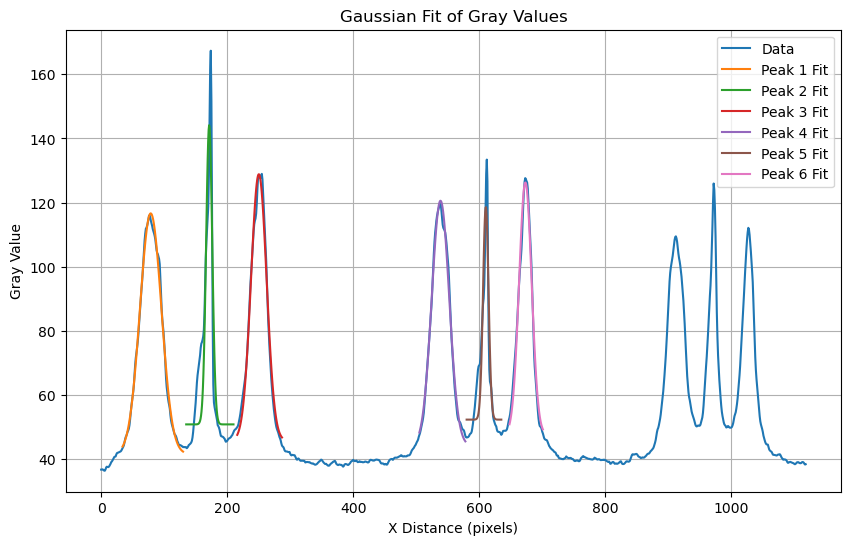

In [11]:
# --- Results and Visualization ---
df_results = pd.DataFrame(results)
print(df_results)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='Data')
for index, row in df_results.iterrows():
    if not np.isnan(row['center']):
        x_fit = np.linspace(peak_ranges[index][0], peak_ranges[index][1], 100)
        y_fit = gaussian(x_fit, row['amplitude'], row['center'], row['sigma'], row['offset'])
        plt.plot(x_fit, y_fit, label=f'Peak {row["peak_number"]} Fit')
plt.xlabel('X Distance (pixels)')
plt.ylabel('Gray Value')
plt.title('Gaussian Fit of Gray Values')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# --- Shift Calculation and FWHM ---
if not df_results.empty:
    centers = df_results['center'].dropna().values
    fwhms = df_results['FWHM'].dropna().values
    if len(centers) >= 6:
        shift_1_2 = centers[1] - centers[0]
        shift_2_3 = centers[2] - centers[1]
        print(f"\nShift between peak 1 and peak 2: {shift_1_2}")
        print(f"Shift between peak 2 and peak 3: {shift_2_3}")
        
        print("\nFWHM values:")
        for i, fwhm in enumerate(fwhms):
            print(f"Peak {i+1}: {fwhm}")
    elif len(centers) == 2:
        shift_1_2 = centers[1] - centers[0]
        print(f"\nShift between peak 1 and peak 2: {shift_1_2}")
        print("\nFWHM values:")
        for i, fwhm in enumerate(fwhms):
            print(f"Peak {i+1}: {fwhm}")
    elif len(centers) == 1:
        print("\nOnly one peak fitted; cannot compute shifts.")
        print("\nFWHM values:")
        for i, fwhm in enumerate(fwhms):
            print(f"Peak {i+1}: {fwhm}")
    else:
        print("\nNo peaks fitted; cannot compute shifts.")



Shift between peak 1 and peak 2: 92.80116350175027
Shift between peak 2 and peak 3: 78.75099985975339

FWHM values:
Peak 1: 39.95671078630417
Peak 2: 11.441138241271867
Peak 3: 29.117385370166232
Peak 4: 32.58420592432122
Peak 5: 10.313457353995398
Peak 6: 23.43877432284356
